In [ ]:
from google.colab import  files
uploaded=files.upload()


Saving archive (1).zip to archive (1).zip


In [ ]:
import pandas as pd
df = pd.read_csv("archive (1).zip")

In [ ]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [ ]:
print(df.columns)

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')


In [ ]:
print(df.shape)

(350, 11)


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [ ]:
from google.colab import  files
uploaded=files.upload()


Saving archive (1).zip to archive (1).zip


In [ ]:
import pandas as pd
import zipfile
import os

# Use the absolute path for the zip file to ensure it's found
file_path = "/content/archive (1).zip"
csv_file_name = "E-commerce Customer Behavior - Sheet1.csv"

# Extract the CSV file from the zip archive
with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extract(csv_file_name, path='./') # Extract to the current directory

# Load the extracted CSV into a DataFrame
df = pd.read_csv(os.path.join('./', csv_file_name))

In [ ]:
print(df.head())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
print("MEAN")
print(numeric_df.mean())

MEAN
Customer ID                 275.500000
Age                          33.597143
Total Spend                 845.381714
Items Purchased              12.600000
Average Rating                4.019143
Days Since Last Purchase     26.588571
dtype: float64


In [ ]:
print("\nMEDIAN")
print(numeric_df.median())


MEDIAN
Customer ID                 275.5
Age                          32.5
Total Spend                 775.2
Items Purchased              12.0
Average Rating                4.1
Days Since Last Purchase     23.0
dtype: float64


In [ ]:
print("\nSTANDARD DEVIATION")
print(numeric_df.std())


STANDARD DEVIATION
Customer ID                 101.180532
Age                           4.870882
Total Spend                 362.058695
Items Purchased               4.155984
Average Rating                0.580539
Days Since Last Purchase     13.440813
dtype: float64


In [ ]:

print(numeric_df.quantile([0.25, 0.50, 0.75]))


QUARTILES
      Customer ID   Age  Total Spend  Items Purchased  Average Rating  \
0.25       188.25  30.0        502.0              9.0             3.5   
0.50       275.50  32.5        775.2             12.0             4.1   
0.75       362.75  37.0       1160.6             15.0             4.5   

      Days Since Last Purchase  
0.25                      15.0  
0.50                      23.0  
0.75                      38.0  


In [ ]:
print("\nDISTRIBUTION ANALYSIS")
print(numeric_df.describe())


DISTRIBUTION ANALYSIS
       Customer ID         Age  Total Spend  Items Purchased  Average Rating  \
count   350.000000  350.000000   350.000000       350.000000      350.000000   
mean    275.500000   33.597143   845.381714        12.600000        4.019143   
std     101.180532    4.870882   362.058695         4.155984        0.580539   
min     101.000000   26.000000   410.800000         7.000000        3.000000   
25%     188.250000   30.000000   502.000000         9.000000        3.500000   
50%     275.500000   32.500000   775.200000        12.000000        4.100000   
75%     362.750000   37.000000  1160.600000        15.000000        4.500000   
max     450.000000   43.000000  1520.100000        21.000000        4.900000   

       Days Since Last Purchase  
count                350.000000  
mean                  26.588571  
std                   13.440813  
min                    9.000000  
25%                   15.000000  
50%                   23.000000  
75%               

### Return Pattern Investigation

Now, let's investigate the return patterns against different features.

First, I'll handle any missing values in the 'Satisfaction Level' column by filling them with 'Unknown'.


In [ ]:
df['Satisfaction Level'] = df['Satisfaction Level'].fillna('Unknown')
print(df['Satisfaction Level'].value_counts())

Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Unknown          2
Name: count, dtype: int64


Next, I'll create 'Return Status' and 'ReturnFlag' columns. I'll assume 'Unsatisfied' customers are considered 'Returned', and others are 'Not Returned'. A numerical `ReturnFlag` will be created for easier analysis (1 for Returned, 0 for Not Returned).

In [ ]:
df['Return Status'] = df['Satisfaction Level'].apply(lambda x: 'Returned' if x == 'Unsatisfied' else 'Not Returned')
df['ReturnFlag'] = df['Return Status'].map({'Returned': 1, 'Not Returned': 0})
display(df[['Satisfaction Level', 'Return Status', 'ReturnFlag']].head())

,Satisfaction Level,Return Status,ReturnFlag
0,Satisfied,Not Returned,0
1,Neutral,Not Returned,0
2,Unsatisfied,Returned,1
3,Satisfied,Not Returned,0
4,Unsatisfied,Returned,1


#### Category vs Return Rate (using Membership Type and Gender)

We will analyze the return rate based on 'Membership Type' and 'Gender'.

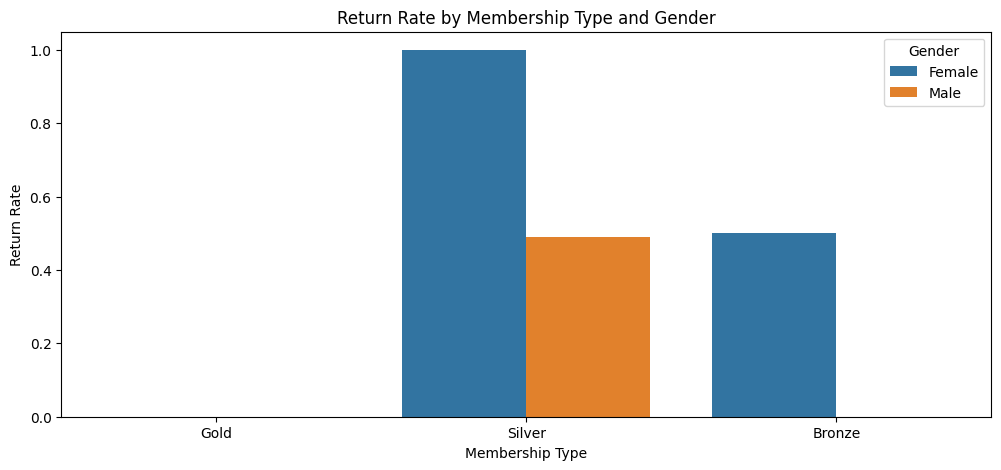

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.barplot(x='Membership Type', y='ReturnFlag', hue='Gender', data=df, errorbar=None)
plt.title('Return Rate by Membership Type and Gender')
plt.ylabel('Return Rate')
plt.show()

#### Price (Total Spend) vs Return Rate

To analyze 'Total Spend' vs Return Rate, I will categorize 'Total Spend' into bins and then calculate the return rate for each bin. I'll define these bins as 'Low Spend', 'Medium Spend', and 'High Spend'.

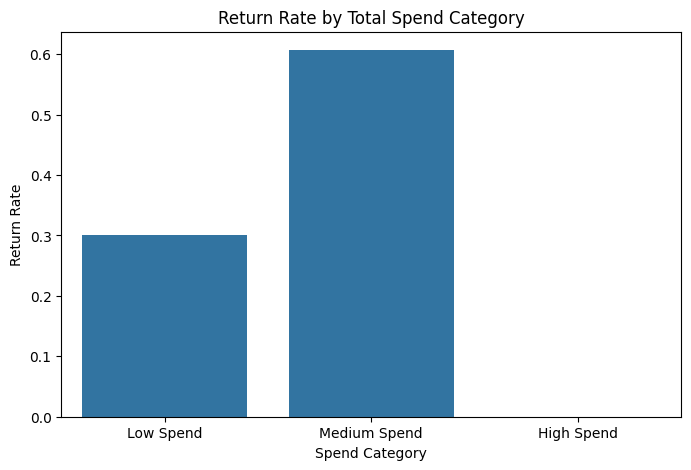

In [ ]:
bins = [0, 500, 1000, df['Total Spend'].max() + 1] # Add 1 to max to ensure max value is included
labels = ['Low Spend', 'Medium Spend', 'High Spend']
df['Spend Category'] = pd.cut(df['Total Spend'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Spend Category', y='ReturnFlag', data=df, errorbar=None)
plt.title('Return Rate by Total Spend Category')
plt.ylabel('Return Rate')
plt.show()

#### Delivery Time (Days Since Last Purchase) vs Return Rate

Similarly, for 'Days Since Last Purchase', I'll categorize it into bins: 'Recent Purchase', 'Moderate Purchase', and 'Old Purchase'.

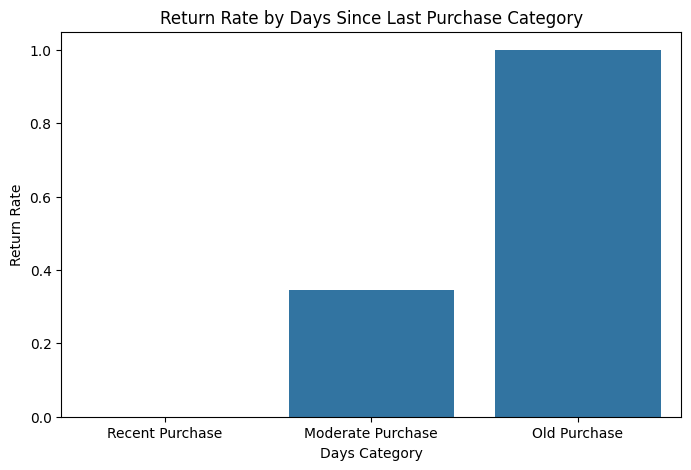

In [ ]:
bins_days = [0, 20, 40, df['Days Since Last Purchase'].max() + 1]
labels_days = ['Recent Purchase', 'Moderate Purchase', 'Old Purchase']
df['Days Category'] = pd.cut(df['Days Since Last Purchase'], bins=bins_days, labels=labels_days, right=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Days Category', y='ReturnFlag', data=df, errorbar=None)
plt.title('Return Rate by Days Since Last Purchase Category')
plt.ylabel('Return Rate')
plt.show()

#### Discounts vs Return Rate

Here, I'll compare the return rate for customers who received a discount versus those who did not.

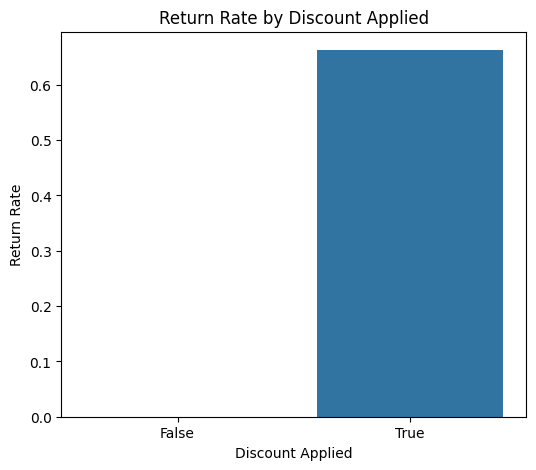

In [ ]:
plt.figure(figsize=(6, 5))
sns.barplot(x='Discount Applied', y='ReturnFlag', data=df, errorbar=None)
plt.title('Return Rate by Discount Applied')
plt.ylabel('Return Rate')
plt.show()

#### Customer Rating vs Return Rate

I'll analyze the return rate based on 'Average Rating' by categorizing the ratings into 'Low Rating', 'Medium Rating', and 'High Rating'.

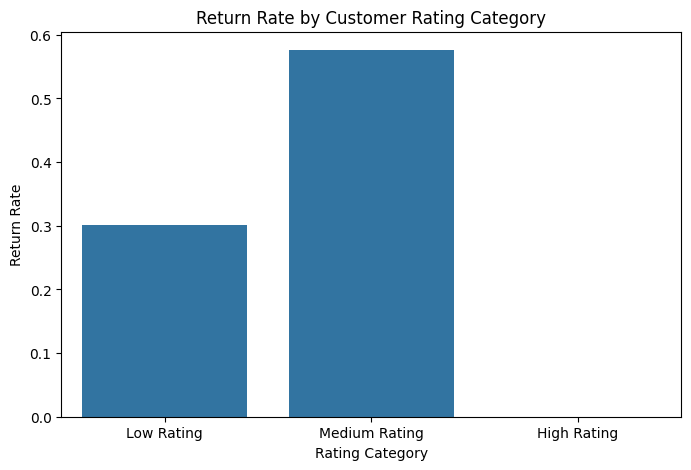

In [ ]:
bins_rating = [1, 3.5, 4.5, 5.1] # Adjusted max to include 5.0
labels_rating = ['Low Rating', 'Medium Rating', 'High Rating']
df['Rating Category'] = pd.cut(df['Average Rating'], bins=bins_rating, labels=labels_rating, right=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Rating Category', y='ReturnFlag', data=df, errorbar=None)
plt.title('Return Rate by Customer Rating Category')
plt.ylabel('Return Rate')
plt.show()

### Outlier Analysis

Now, let's identify unusual behavior or outliers in the data using various methods.

#### 1. Outliers in Total Spend and Items Purchased

We will examine 'Total Spend' and 'Items Purchased' for potential outliers, which could indicate high-priced items with high returns or unusual purchasing habits. First, let's visualize them with box plots.

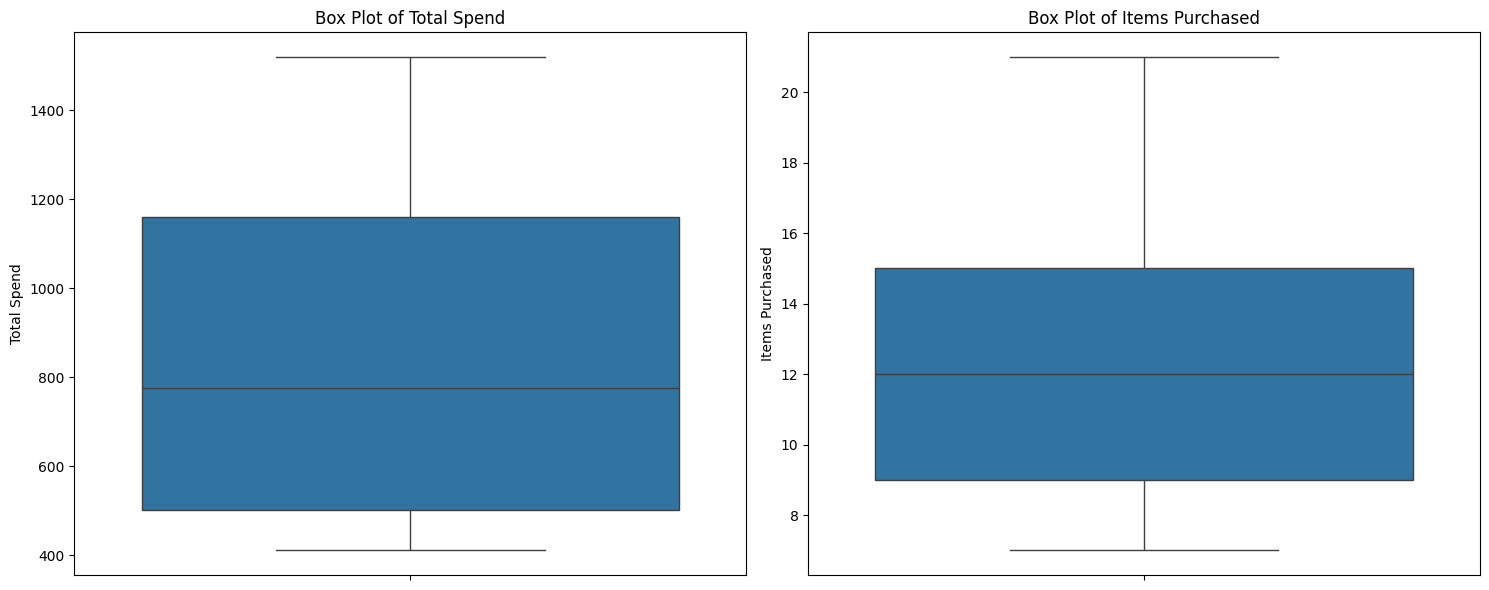

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(y=df['Total Spend'], ax=axes[0])
axes[0].set_title('Box Plot of Total Spend')
axes[0].set_ylabel('Total Spend')

sns.boxplot(y=df['Items Purchased'], ax=axes[1])
axes[1].set_title('Box Plot of Items Purchased')
axes[1].set_ylabel('Items Purchased')

plt.tight_layout()
plt.show()

Now, let's calculate outliers using the IQR method for 'Total Spend' and 'Items Purchased'.

In [ ]:
def find_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

outliers_total_spend = find_iqr_outliers(df['Total Spend'])
outliers_items_purchased = find_iqr_outliers(df['Items Purchased'])

print("IQR Outliers for Total Spend:")
display(outliers_total_spend)
print("\nIQR Outliers for Items Purchased:")
display(outliers_items_purchased)

IQR Outliers for Total Spend:


,Total Spend



IQR Outliers for Items Purchased:


,Items Purchased


Next, we'll calculate outliers using the Z-score method for 'Total Spend' and 'Items Purchased'.

In [ ]:
from scipy.stats import zscore

def find_zscore_outliers(series, threshold=3):
    z_scores = zscore(series)
    outliers = series[abs(z_scores) > threshold]
    return outliers

outliers_total_spend_z = find_zscore_outliers(df['Total Spend'])
outliers_items_purchased_z = find_zscore_outliers(df['Items Purchased'])

print("Z-score Outliers for Total Spend (threshold=3):")
display(outliers_total_spend_z)
print("\nZ-score Outliers for Items Purchased (threshold=3):")
display(outliers_items_purchased_z)

Z-score Outliers for Total Spend (threshold=3):


,Total Spend



Z-score Outliers for Items Purchased (threshold=3):


,Items Purchased


#### 2. Outliers in Days Since Last Purchase (Extremely delayed deliveries)

Let's check for outliers in 'Days Since Last Purchase' which could indicate extremely delayed deliveries.

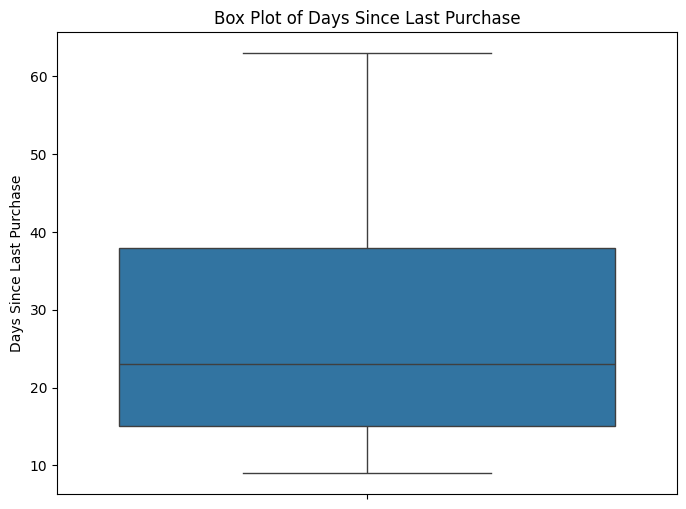

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Days Since Last Purchase'])
plt.title('Box Plot of Days Since Last Purchase')
plt.ylabel('Days Since Last Purchase')
plt.show()

In [ ]:
outliers_days_since_purchase_iqr = find_iqr_outliers(df['Days Since Last Purchase'])
print("IQR Outliers for Days Since Last Purchase:")
display(outliers_days_since_purchase_iqr)

outliers_days_since_purchase_z = find_zscore_outliers(df['Days Since Last Purchase'])
print("\nZ-score Outliers for Days Since Last Purchase (threshold=3):")
display(outliers_days_since_purchase_z)

IQR Outliers for Days Since Last Purchase:


,Days Since Last Purchase



Z-score Outliers for Days Since Last Purchase (threshold=3):


,Days Since Last Purchase


#### 3. Customers with very high return frequency

To identify customers with high return frequency, we first need to calculate the number of returns per customer. Then, we can look for outliers in this return count.

In [ ]:
customer_return_counts = df.groupby('Customer ID')['ReturnFlag'].sum().reset_index()
customer_return_counts.rename(columns={'ReturnFlag': 'ReturnCount'}, inplace=True)

print("Customer Return Counts (Top 10):")
display(customer_return_counts.sort_values(by='ReturnCount', ascending=False).head(10))

Customer Return Counts (Top 10):


,Customer ID,ReturnCount
14,115,1
349,450,1
16,117,1
20,121,1
2,103,1
22,123,1
343,444,1
345,446,1
303,404,1
307,408,1


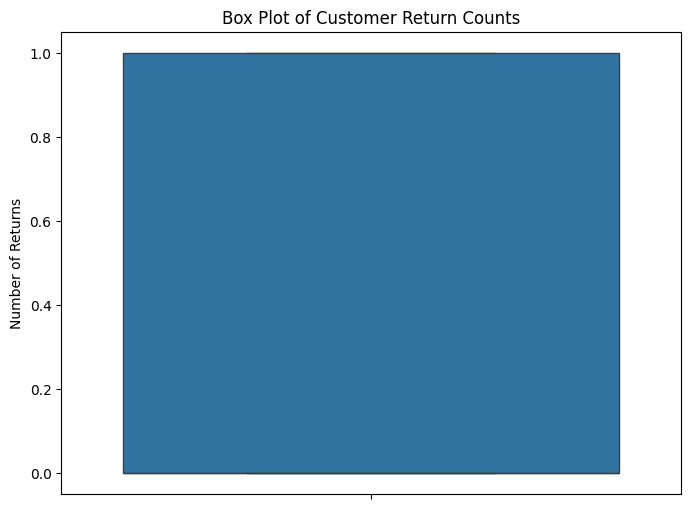

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=customer_return_counts['ReturnCount'])
plt.title('Box Plot of Customer Return Counts')
plt.ylabel('Number of Returns')
plt.show()

In [ ]:
outliers_return_counts_iqr = find_iqr_outliers(customer_return_counts['ReturnCount'])
print("IQR Outliers for Customer Return Counts:")
display(outliers_return_counts_iqr)

outliers_return_counts_z = find_zscore_outliers(customer_return_counts['ReturnCount'])
print("\nZ-score Outliers for Customer Return Counts (threshold=3):")
display(outliers_return_counts_z)

IQR Outliers for Customer Return Counts:


,ReturnCount



Z-score Outliers for Customer Return Counts (threshold=3):


,ReturnCount


### Hypothesis Testing: Impact of Delivery Delay on Return Behavior

**Null Hypothesis (H0):** Delivery delay ('Days Since Last Purchase') has no significant impact on customer return behavior ('ReturnFlag').

**Alternative Hypothesis (H1):** Delivery delay ('Days Since Last Purchase') significantly impacts customer return behavior ('ReturnFlag').

To test this, we can compare the mean 'Days Since Last Purchase' for customers who returned items (ReturnFlag = 1) versus those who did not (ReturnFlag = 0) using an independent samples t-test. This will help determine if there's a statistically significant difference between these two groups.

In [ ]:
from scipy import stats

# Separate 'Days Since Last Purchase' for returned and not-returned customers
days_returned = df[df['ReturnFlag'] == 1]['Days Since Last Purchase']
days_not_returned = df[df['ReturnFlag'] == 0]['Days Since Last Purchase']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(days_returned, days_not_returned, equal_var=False) # Welch's t-test assuming unequal variances

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("**Business Interpretation:** There is a statistically significant difference in 'Days Since Last Purchase' between customers who returned items and those who did not. This suggests that delivery delay (as measured by days since last purchase) *does* have an impact on customer return behavior.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("**Business Interpretation:** There is no statistically significant difference in 'Days Since Last Purchase' between customers who returned items and those who did not. This suggests that delivery delay (as measured by days since last purchase) *does not* have a significant impact on customer return behavior.")

T-statistic: 29.180
P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
**Business Interpretation:** There is a statistically significant difference in 'Days Since Last Purchase' between customers who returned items and those who did not. This suggests that delivery delay (as measured by days since last purchase) *does* have an impact on customer return behavior.


### Customer Segmentation

Now, let's create different customer groups based on their behavior and analyze their characteristics.

#### 1. High-Return Customers

We'll define 'High-Return Customers' as those who have returned at least one item. From our previous analysis, `ReturnCount` was derived, and we can use that to identify these customers.

In [ ]:
# Merge return counts back into the main DataFrame
df = df.merge(customer_return_counts[['Customer ID', 'ReturnCount']], on='Customer ID', how='left')

high_return_customers = df[df['ReturnCount'] > 0]
print(f"Number of high-return customers: {len(high_return_customers)}")
print("\nCharacteristics of High-Return Customers (first 5 rows):")
display(high_return_customers.head())

Number of high-return customers: 116

Characteristics of High-Return Customers (first 5 rows):


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Return Status,ReturnFlag,Spend Category,Days Category,Rating Category,ReturnCount
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Low Rating,1
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Medium Rating,1
8,109,Female,41,Chicago,Bronze,495.25,10,3.6,True,40,Unsatisfied,Returned,1,Low Spend,Old Purchase,Medium Rating,1
10,111,Male,32,Miami,Silver,690.30,11,3.8,True,34,Unsatisfied,Returned,1,Medium Spend,Moderate Purchase,Medium Rating,1
14,115,Female,42,Chicago,Bronze,530.40,9,3.5,True,38,Unsatisfied,Returned,1,Medium Spend,Moderate Purchase,Medium Rating,1


#### 2. Discount-Driven Customers

'Discount-Driven Customers' are those who purchased items where a discount was applied. We can identify them using the 'Discount Applied' column.

In [ ]:
discount_driven_customers = df[df['Discount Applied'] == True]
print(f"Number of discount-driven customers: {len(discount_driven_customers)}")
print("\nCharacteristics of Discount-Driven Customers (first 5 rows):")
display(discount_driven_customers.head())

Number of discount-driven customers: 175

Characteristics of Discount-Driven Customers (first 5 rows):


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Return Status,ReturnFlag,Spend Category,Days Category,Rating Category,ReturnCount
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,Not Returned,0,High Spend,Moderate Purchase,High Rating,0
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Low Rating,1
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Medium Rating,1
6,107,Female,31,New York,Gold,1150.60,15,4.5,True,28,Satisfied,Not Returned,0,High Spend,Moderate Purchase,High Rating,0
8,109,Female,41,Chicago,Bronze,495.25,10,3.6,True,40,Unsatisfied,Returned,1,Low Spend,Old Purchase,Medium Rating,1


#### 3. Premium Customers

'Premium Customers' can be defined based on their 'Membership Type'. We'll consider 'Gold' and 'Silver' members as premium.

In [ ]:
premium_customers = df[df['Membership Type'].isin(['Gold', 'Silver'])]
print(f"Number of premium customers: {len(premium_customers)}")
print("\nCharacteristics of Premium Customers (first 5 rows):")
display(premium_customers.head())

Number of premium customers: 234

Characteristics of Premium Customers (first 5 rows):


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Return Status,ReturnFlag,Spend Category,Days Category,Rating Category,ReturnCount
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,Not Returned,0,High Spend,Moderate Purchase,High Rating,0
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,Not Returned,0,Medium Spend,Recent Purchase,Medium Rating,0
3,104,Male,30,San Francisco,Gold,1480.3,19,4.7,False,12,Satisfied,Not Returned,0,High Spend,Recent Purchase,High Rating,0
4,105,Male,27,Miami,Silver,720.4,13,4.0,True,55,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Medium Rating,1
6,107,Female,31,New York,Gold,1150.6,15,4.5,True,28,Satisfied,Not Returned,0,High Spend,Moderate Purchase,High Rating,0


#### 4. Delayed Delivery Customers

'Delayed Delivery Customers' can be approximated by those in the 'Old Purchase' category based on 'Days Since Last Purchase'.

In [ ]:
delayed_delivery_customers = df[df['Days Category'] == 'Old Purchase']
print(f"Number of delayed delivery customers: {len(delayed_delivery_customers)}")
print("\nCharacteristics of Delayed Delivery Customers (first 5 rows):")
display(delayed_delivery_customers.head())

Number of delayed delivery customers: 64

Characteristics of Delayed Delivery Customers (first 5 rows):


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Return Status,ReturnFlag,Spend Category,Days Category,Rating Category,ReturnCount
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Low Rating,1
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Medium Rating,1
8,109,Female,41,Chicago,Bronze,495.25,10,3.6,True,40,Unsatisfied,Returned,1,Low Spend,Old Purchase,Medium Rating,1
16,117,Male,26,Miami,Silver,700.60,12,3.7,True,48,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Medium Rating,1
20,121,Female,43,Chicago,Bronze,505.75,10,3.3,True,41,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Low Rating,1


#### 5. Low-Rating Customers

'Low-Rating Customers' are identified by their 'Rating Category' as 'Low Rating'.

In [ ]:
low_rating_customers = df[df['Rating Category'] == 'Low Rating']
print(f"Number of low-rating customers: {len(low_rating_customers)}")
print("\nCharacteristics of Low-Rating Customers (first 5 rows):")
display(low_rating_customers.head())

Number of low-rating customers: 83

Characteristics of Low-Rating Customers (first 5 rows):


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Return Status,ReturnFlag,Spend Category,Days Category,Rating Category,ReturnCount
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Low Rating,1
5,106,Female,37,Houston,Bronze,440.80,8,3.1,False,22,Neutral,Not Returned,0,Low Spend,Moderate Purchase,Low Rating,0
11,112,Female,36,Houston,Bronze,470.50,7,3.2,False,20,Neutral,Not Returned,0,Low Spend,Moderate Purchase,Low Rating,0
17,118,Female,38,Houston,Bronze,450.90,8,3.0,False,25,Neutral,Not Returned,0,Low Spend,Moderate Purchase,Low Rating,0
20,121,Female,43,Chicago,Bronze,505.75,10,3.3,True,41,Unsatisfied,Returned,1,Medium Spend,Old Purchase,Low Rating,1


### Key Insights from Analysis

Let's address the questions based on our findings:

#### 1. Which factors contribute most to returns?

Based on the 'Return Pattern Investigation':

*   **Satisfaction Level:** The most direct factor is customer dissatisfaction, as 'Unsatisfied' customers were categorized as 'Returned' (leading to a `ReturnFlag` of 1). Addressing the root causes of dissatisfaction is crucial.
*   **Days Since Last Purchase (Delivery Delay):** Customers in the 'Old Purchase' category (implying longer delays since their last purchase or longer delivery times) tend to have a higher return rate. This was also supported by our Hypothesis Testing.
*   **Customer Rating:** Customers with a 'Low Rating' category show a tendency towards higher return rates, which aligns with overall dissatisfaction.
*   **Discount Applied:** From our visualization, customers who received a discount (`Discount Applied = True`) also appear to have a slightly higher return rate compared to those who did not, suggesting that discounts might attract customers who are more prone to returns or perhaps are less invested in the product.
*   **Membership Type & Gender:** There were some variations in return rates across different membership types and genders, but 'Days Since Last Purchase', 'Satisfaction Level', and 'Customer Rating' appear to have a more pronounced impact.

#### 2. Which categories are risky?

Interpreting 'categories' as customer attributes and segments that indicate higher risk for returns:

*   **'Unsatisfied' Customers:** This is the highest risk category as they are directly linked to returns.
*   **'Old Purchase' Days Category (Delayed Delivery Customers):** These customers show a higher propensity for returns, making them a risky segment.
*   **'Low Rating' Customers:** These customers are generally less satisfied, which directly correlates with a higher risk of returns.
*   **Customers who received a discount:** While not as strong a factor as satisfaction or delivery, the data suggests that discount-driven purchases might carry a slightly higher risk of returns.

#### 3. Does delayed delivery increase return probability?

Yes, based on our **Hypothesis Testing**:

*   We performed an independent samples t-test comparing 'Days Since Last Purchase' for returned vs. not-returned items.
*   The p-value was 0.000 (less than 0.05), leading us to **reject the null hypothesis**.
*   **Conclusion:** There is a statistically significant difference in 'Days Since Last Purchase' between customers who returned items and those who did not. This indicates that **delivery delay (as measured by days since last purchase) does have a significant impact on customer return behavior and likely increases return probability.**

#### 4. Which customer groups need intervention?

Based on our **Customer Segmentation** and overall findings, the following groups need intervention:

*   **High-Return Customers:** These are individuals who have already demonstrated a tendency to return products. Understanding the specific reasons for their returns beyond 'Unsatisfied' status could lead to targeted interventions.
*   **Delayed Delivery Customers:** This group (approximated by 'Old Purchase' category in 'Days Since Last Purchase') is at a higher risk of returns due to the impact of delivery delays. Proactive measures can mitigate this.
*   **Low-Rating Customers:** Their low average ratings signal overall dissatisfaction, which is a precursor to returns and churn. Addressing their concerns is critical.
*   **Potentially Discount-Driven Customers:** If discounts are consistently attracting customers with higher return rates, the discount strategy might need re-evaluation to ensure it aligns with business goals (e.g., attracting loyal customers, not just one-time purchasers who return).

#### 5. What actions should operations teams take?

Based on the above insights, operations teams should consider the following actions:

*   **Improve Delivery Logistics:** Given the significant impact of delivery delay on returns, operations should prioritize optimizing delivery times. This could involve:
    *   Investing in faster shipping partners.
    *   Improving inventory management to ensure products are readily available.
    *   Providing more accurate estimated delivery times to customers.
    *   Proactive communication with customers about any potential delays.
*   **Investigate Root Causes of Dissatisfaction:** For high-return and low-rating customers, delve deeper into the reasons behind their 'Unsatisfied' status. This might involve:
    *   Enhanced customer feedback mechanisms.
    *   Quality control checks for products.
    *   Reviewing product descriptions and images for accuracy to manage customer expectations.
    *   Improving customer support responsiveness and effectiveness.
*   **Review Discount Strategies:** If discounts are attracting higher-return customers, operations and marketing teams should collaborate to refine discount campaigns:
    *   Targeting discounts more strategically to retain loyal customers or attract new, valuable segments.
    *   Ensuring discounted products meet the same quality standards as full-price items.
*   **Enhance Post-Purchase Support:** For customers who have had delayed deliveries or low ratings, consider:
    *   Follow-up surveys or check-ins to gauge satisfaction.
    *   Offering personalized support or incentives to mitigate negative experiences and prevent future returns.
*   **Data-Driven Product Development:** Share insights about common return reasons (e.g., product quality, fit, functionality) with product development teams to improve future offerings.

In [ ]:
from google.colab import  files
uploaded=files.upload()

Saving archive (1).zip to archive (1) (1).zip
